<a href="https://colab.research.google.com/github/tmorenom/MyRep_TMM2025/blob/main/Actividad2analisisPandas_A01840597.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: TERESA DE JESUS MORENO MARTINEZ
*   MATRÍCULA: A01840597


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [ ]:
# Importa las librerías necesarias
import pandas as Pds
import datetime
import matplotlib.pyplot as Mplt
import seaborn as SB

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [ ]:
#Descarga el archivo: cleaned_weather.csv y guarda, en un dataframe (weather_df), todos sus registros.
weather_df=Pds.read_csv ('cleaned_weather.csv')

#Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
print(f'Dimensiones (filas, columnas): {weather_df.shape}')
print(f'Número de filas: {weather_df.shape[0]}')
print(f'Número de columnas: {weather_df.shape[1]}')
columnas = weather_df.columns
print(f'Columnas: {list(columnas)}')

# Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes
nuevas_columnas = [
    'Medición', 'Presión_atmosférica', 'Temperatura_Celsius', 'Temperatura_Kelvin',
    'Humedad_Relativa', 'Presión_Vapor', 'Humedad_Específica', 'Concentración_Vapor',
    'Densidad_Aire', 'Velocidad_Viento', 'Dirección_Viento', 'Precipitación_Total',
    'Duración_Lluvia'
]
weather_df.columns = nuevas_columnas

#Muestra los primeros y los últimos 5 registros

print('\nPrimeros 5 registros:')
print(weather_df.head())

print('\nÚltimos 5 registros:')
print(weather_df.tail())

#¿Hay valores faltantes en el dataframe?
print('\nValores faltantes:')

print(weather_df.isnull().sum())

Dimensiones (filas, columnas): (52696, 13)
Número de filas: 52696
Número de columnas: 13
Columnas: ['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv', 'wd', 'rain', 'raining']

Primeros 5 registros:
        Medición  Presión_atmosférica  Temperatura_Celsius  \
0  01/01/20 0:10              1008.89                 0.71   
1  01/01/20 0:20              1008.76                 0.75   
2  01/01/20 0:30              1008.66                 0.73   
3  01/01/20 0:40              1008.64                 0.37   
4  01/01/20 0:50              1008.61                 0.33   

   Temperatura_Kelvin  Humedad_Relativa  Presión_Vapor  Humedad_Específica  \
0              273.18              86.1           5.54                3.42   
1              273.22              85.2           5.49                3.39   
2              273.21              85.1           5.48                3.39   
3              272.86              86.3           5.41                3.35   
4              2

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime.
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`.

In [ ]:
#Determina el tipo de datos que tienen las columnas
print(weather_df.dtypes)

# Cambia la columna 'Medición' a datetime
#datetime.strptime(fecha_str, "%d/%m/%y %H:%M")
weather_df['Medición'] = Pds.to_datetime(weather_df['Medición'], format='%d/%m/%y %H:%M')


# Obtén dos columnas adicionales separando medición en 'fecha' y 'hora'

#weather_df['Fecha'] = Pds.to_datetime(weather_df['Medición'], format='%d/%m/%y')
#weather_df['Hora'] = Pds.to_datetime(weather_df['Medición'], format='%H/%M/')
weather_df['Fecha'] = weather_df['Medición'].dt.date
weather_df['Hora'] = weather_df['Medición'].dt.time

print(weather_df.dtypes)

Medición                object
Presión_atmosférica    float64
Temperatura_Celsius    float64
Temperatura_Kelvin     float64
Humedad_Relativa       float64
Presión_Vapor          float64
Humedad_Específica     float64
Concentración_Vapor    float64
Densidad_Aire          float64
Velocidad_Viento       float64
Dirección_Viento       float64
Precipitación_Total    float64
Duración_Lluvia          int64
dtype: object
Medición               datetime64[ns]
Presión_atmosférica           float64
Temperatura_Celsius           float64
Temperatura_Kelvin            float64
Humedad_Relativa              float64
Presión_Vapor                 float64
Humedad_Específica            float64
Concentración_Vapor           float64
Densidad_Aire                 float64
Velocidad_Viento              float64
Dirección_Viento              float64
Precipitación_Total           float64
Duración_Lluvia                 int64
Fecha                          object
Hora                           object
dtype: object

3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [ ]:
#Determina la cantidad de valores únicos de cada columna.

print('Cantidad de valores únicos por columna:')
print(weather_df.nunique())

# La columna medicion tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
Medicion_duplicada = weather_df[weather_df.duplicated(subset=['Medición'], keep=False)]
print('Medicion_duplicada:')

#Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina uno de los registros duplicados.


if not Medicion_duplicada.empty:
    print('\nRegistros duplicados (incluyendo medicion):')
    print(Medicion_duplicada)


    Medicion_duplicada = weather_df.shape[0]
    weather_df.drop_duplicates(inplace=True)
    Borrar = Medicion_duplicada - weather_df.shape[0]

    print(f'\nSe eliminaron registros duplicados')
    NewFilas_duplicadas = weather_df[weather_df.duplicated(keep=False)]
    print(NewFilas_duplicadas)

else:
    print(f'\nNo hay registros duplicados')

print(weather_df.nunique())




Cantidad de valores únicos por columna:
Medición               52695
Presión_atmosférica     5052
Temperatura_Celsius     3680
Temperatura_Kelvin      3836
Humedad_Relativa        5494
Presión_Vapor           2059
Humedad_Específica      1337
Concentración_Vapor     2087
Densidad_Aire          14826
Velocidad_Viento         977
Dirección_Viento        8099
Precipitación_Total       42
Duración_Lluvia           61
Fecha                    367
Hora                     144
dtype: int64
Medicion_duplicada:

Registros duplicados (incluyendo medicion):
                 Medición  Presión_atmosférica  Temperatura_Celsius  \
19043 2020-05-12 06:00:00               991.53                -1.57   
19044 2020-05-12 06:00:00               991.53                -1.57   

       Temperatura_Kelvin  Humedad_Relativa  Presión_Vapor  \
19043              272.25              96.2           5.24   
19044              272.25              96.2           5.24   

       Humedad_Específica  Concentración_Vapor

4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [ ]:
# Imprime nuevamente la cantidad de valores únicos por columna.

print('Cantidad de valores únicos por columna:')
print(weather_df.nunique())

# Obtén las mediciones existentes en el dataframe
MedidasAct = Pds.DatetimeIndex(weather_df['Medición'])

# Identifica las fechas en las que faltan mediciones
MedidasAct = Pds.DatetimeIndex(weather_df['Medición'])

# Extrae las fechas únicas de las mediciones faltantes
FechasFal = MedidasAct.normalize().unique()

print(f'Fechas con mediciones faltantes: {len(FechasFal)} días')
if len(FechasFal) > 0:
    print(FechasFal)
    weather_df = weather_df[weather_df['Medición'].dt.year == 2020]

# Eliminar la columna 'Medición'
    weather_df = weather_df.drop(columns=['Medición'])
    print(weather_df.head())
else:
    print('No hay fechas con mediciones faltantes.')

Cantidad de valores únicos por columna:
Medición               52695
Presión_atmosférica     5052
Temperatura_Celsius     3680
Temperatura_Kelvin      3836
Humedad_Relativa        5494
Presión_Vapor           2059
Humedad_Específica      1337
Concentración_Vapor     2087
Densidad_Aire          14826
Velocidad_Viento         977
Dirección_Viento        8099
Precipitación_Total       42
Duración_Lluvia           61
Fecha                    367
Hora                     144
dtype: int64
Fechas con mediciones faltantes: 367 días
DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10',
               ...
               '2020-12-23', '2020-12-24', '2020-12-25', '2020-12-26',
               '2020-12-27', '2020-12-28', '2020-12-29', '2020-12-30',
               '2020-12-31', '2021-01-01'],
              dtype='datetime64[ns]', name='Medición', length=367, freq=None)
  

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [ ]:
# Obtén un dataframe indicadores_diarios que sólo almacene el mayor valor de las mediciones por fecha
Ind_diarios = weather_df.groupby('Fecha').max().reset_index()

# ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
Prec_max = Ind_diarios['Precipitación_Total'].max()
Fmax_precipitacion = Ind_diarios.loc[Ind_diarios['Precipitación_Total'].idxmax(), 'Fecha']

print(f"Máxima precipitación: {Prec_max} mm en la fecha {Fmax_precipitacion}")

# ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
Vviento_altas = Ind_diarios.nlargest(3, 'Velocidad_Viento')[['Fecha', 'Velocidad_Viento']]
print("\nTres días con las velocidades de viento más altas:")
print(Vviento_altas)

# ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?
CD = Ind_diarios[
    (Ind_diarios['Humedad_Relativa'] > 90) &
    (Ind_diarios['Temperatura_Celsius'] > 30)
]
Conteo_dias = len(CD)

print(f"\nCantidad de días con más del 90% de humedad relativa y más de 30° Celsius: {Conteo_dias}")
if Conteo_dias > 0:
    print("Días que cumplen la condición:")
    print(CD[['Fecha', 'Humedad_Relativa', 'Temperatura_Celsius']])

Máxima precipitación: 11.2 mm en la fecha 2020-06-16

Tres días con las velocidades de viento más altas:
         Fecha  Velocidad_Viento
40  2020-02-10             13.77
46  2020-02-16             13.00
39  2020-02-09             12.52

Cantidad de días con más del 90% de humedad relativa y más de 30° Celsius: 5
Días que cumplen la condición:
          Fecha  Humedad_Relativa  Temperatura_Celsius
223  2020-08-11              93.8                31.42
224  2020-08-12              94.4                32.26
232  2020-08-20              97.1                30.38
233  2020-08-21              94.7                34.56
258  2020-09-15              99.9                30.16


6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [ ]:
# Aplica la función describe() al dataframe indicadores_diarios
FDescribe = Ind_diarios.describe()
print('Estadísticas descriptivas del dataframe indicadores_diarios:')
print(FDescribe)

# ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
DS_CV = FDescribe.loc['std', 'Concentración_Vapor']
print(f"\nDesviación estándar de Concentración_Vapor: {DS_CV:.2f}")
print("Esto indica la dispersión promedio de los valores de concentración de vapor alrededor de su media diaria.")

# ¿Cuál es la mediana de la presión atmosférica y qué significa?
mediana_presion_atmosferica = FDescribe.loc['50%', 'Presión_atmosférica']
print(f"\nMediana de Presión_atmosférica: {mediana_presion_atmosferica:.2f}")
print("La mediana representa el valor central de la presión atmosférica cuando los datos están ordenados, dividiendo el 50% inferior del 50% superior.")

# ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?
Tercer_CDL = FDescribe.loc['75%', 'Duración_Lluvia']
print(f"\nTercer cuartil de Duración_Lluvia: {Tercer_CDL:.2f}")
print("El 75% de los días tuvieron una duración de lluvia igual o inferior a este valor.")

Estadísticas descriptivas del dataframe indicadores_diarios:
       Presión_atmosférica  Temperatura_Celsius  Temperatura_Kelvin  \
count           366.000000           366.000000          366.000000   
mean            992.977842            15.343770          289.431667   
std               8.543447             7.850339            7.942175   
min             959.900000            -0.120000          273.460000   
25%             988.015000             8.840000          282.732500   
50%             993.300000            15.060000          289.160000   
75%             998.432500            21.695000          295.957500   
max            1020.070000            34.800000          309.130000   

       Humedad_Relativa  Presión_Vapor  Humedad_Específica  \
count        366.000000     366.000000          366.000000   
mean          90.886530      11.409454            7.214016   
std            9.201588       4.507555            2.872647   
min           55.440000       3.320000            2

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

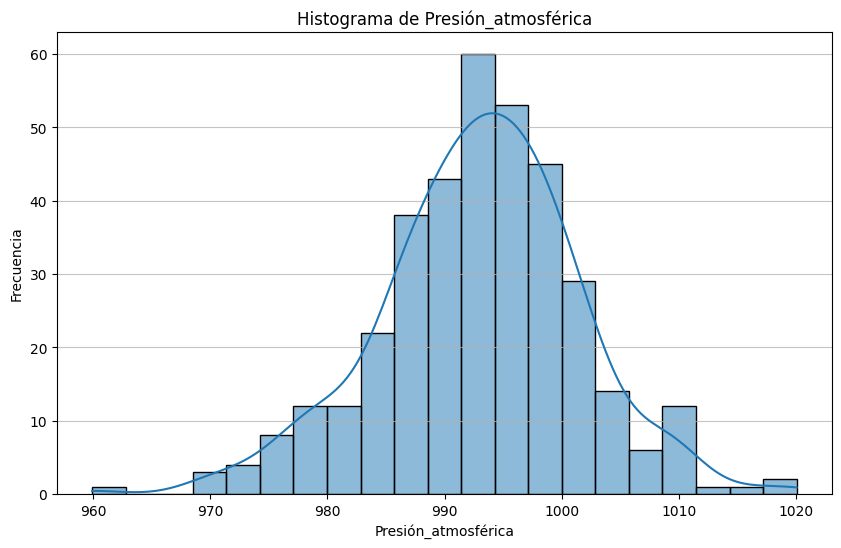

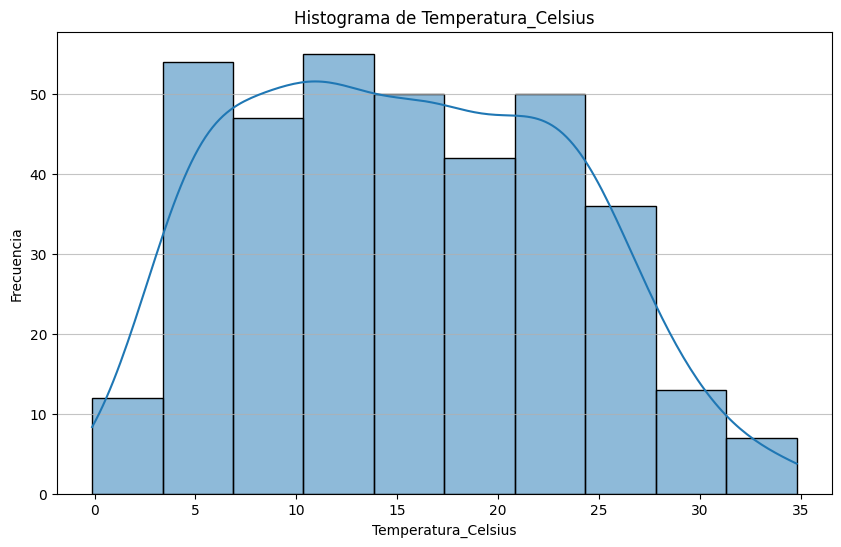

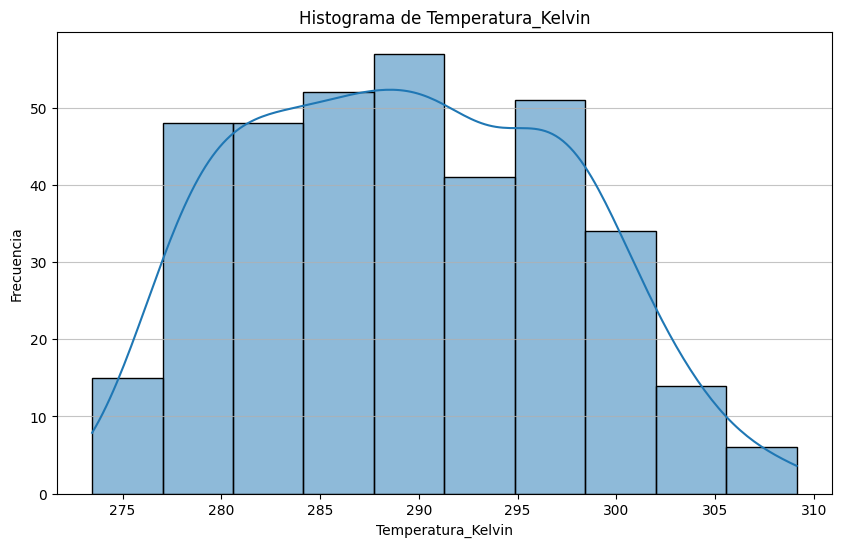

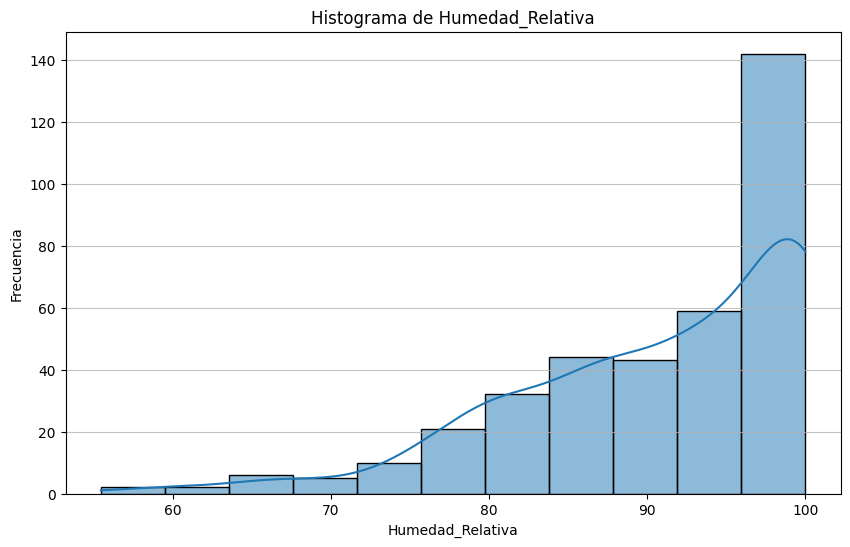

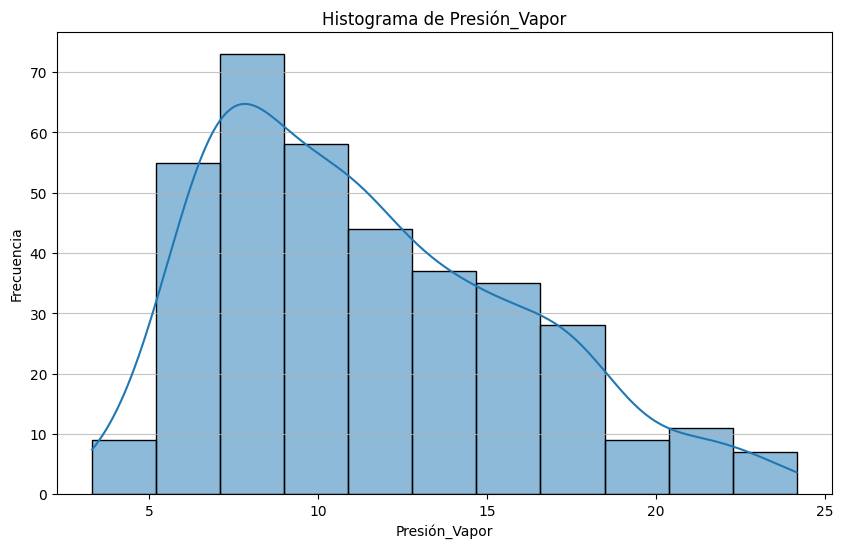

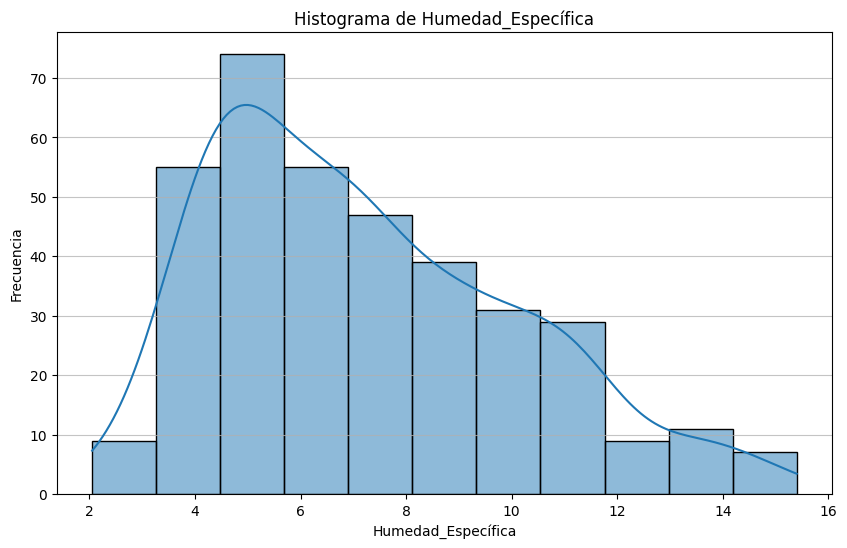

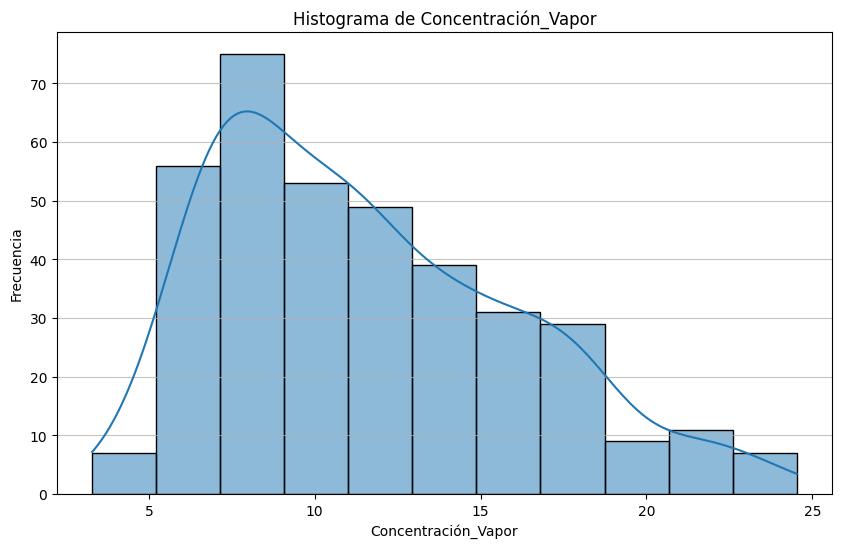

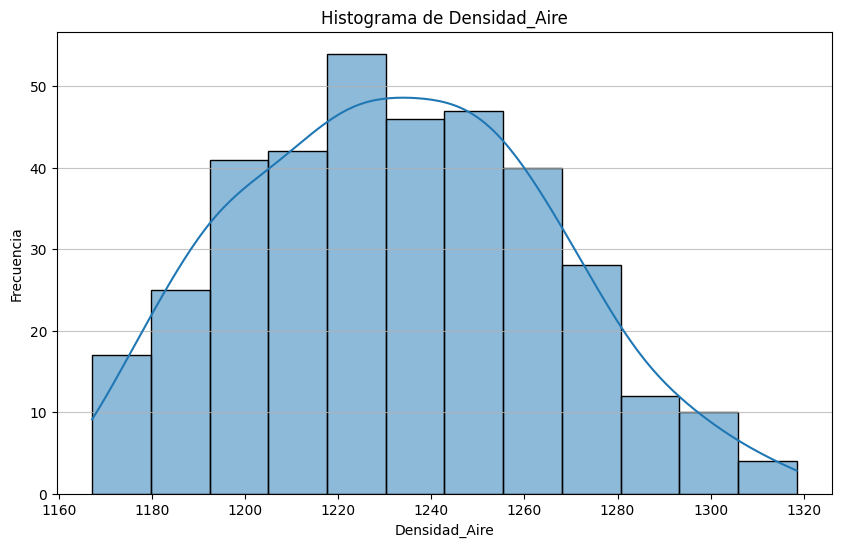

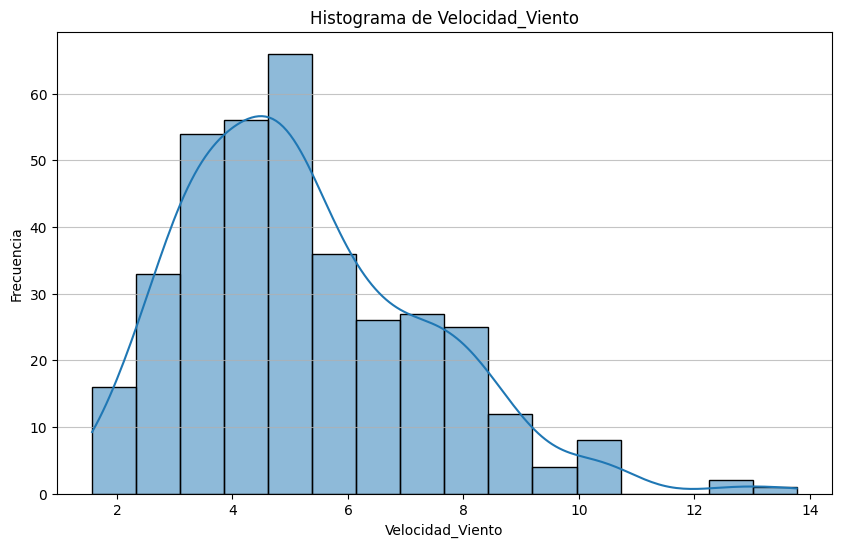

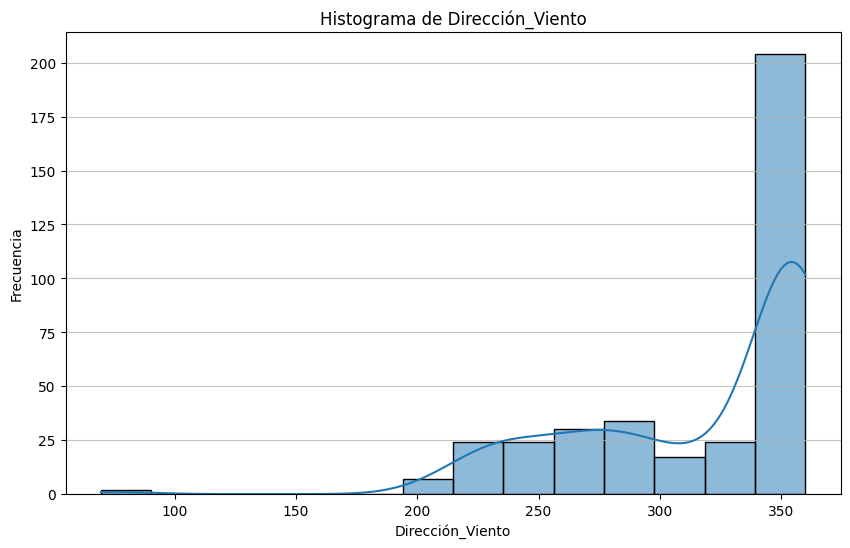

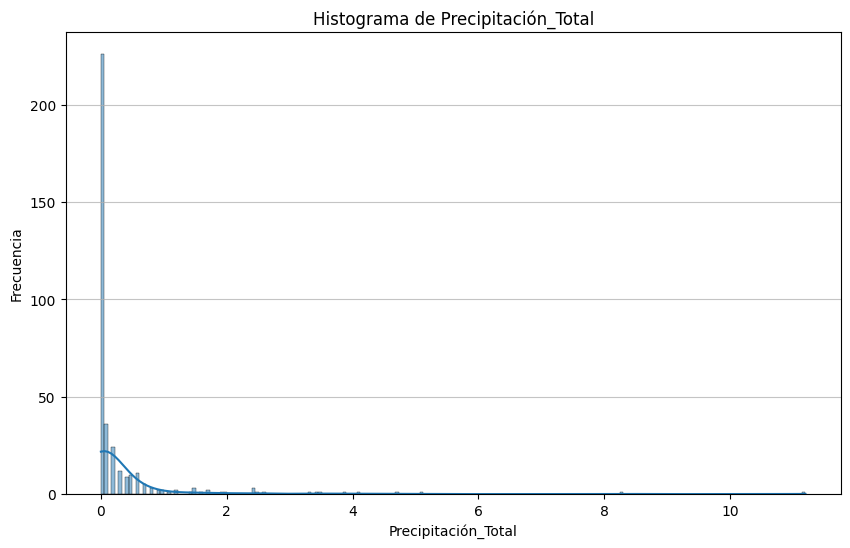

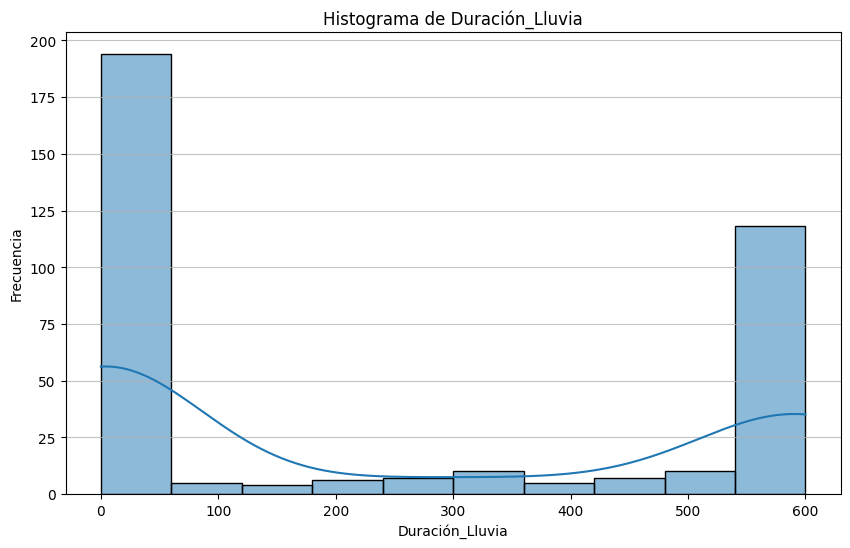

In [ ]:
import matplotlib.pyplot as MPlt
import seaborn as SB

# Obtener las columnas numéricas para graficar histogramas
ColNum = Ind_diarios.select_dtypes(include=['number']).columns

# Crear un histograma para cada columna numérica
for col in ColNum:
    MPlt.figure(figsize=(10, 6))
    SB.histplot(Ind_diarios[col], kde=True)
    MPlt.title(f'Histograma de {col}')
    MPlt.xlabel(col)
    MPlt.ylabel('Frecuencia')
    MPlt.grid(axis='y', alpha=0.75)
    MPlt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [ ]:
# Crea una nueva columna mes` a partir de la fecha que se encuentra en el índice.
Ind_diarios['Fecha'] = Pds.to_datetime(Ind_diarios['Fecha'])
Ind_diarios['mes'] = Ind_diarios['Fecha'].dt.month

# Haciendo uso de groupby(), calcula los promedios mensuales y conserva únicamente las columnas
# humedad_relativa, temperatura_celsius y velocidad_viento en el nuevo dataframe.
Ind_mes = Ind_diarios.groupby('mes')[['Humedad_Relativa', 'Temperatura_Celsius', 'Velocidad_Viento']].mean()

print("DataFrame Ind_mes:")
print(Ind_mes.head())
print("\nTipos de datos de indicadores_mensuales:")
print(Ind_mes.dtypes)

DataFrame Ind_mes:
     Humedad_Relativa  Temperatura_Celsius  Velocidad_Viento
mes                                                         
1           89.776129             6.821290          5.031935
2           85.719655             8.962414          7.489655
3           85.372903             9.683871          6.421290
4           80.938667            16.879667          4.997000
5           87.464839            17.135484          4.865806

Tipos de datos de indicadores_mensuales:
Humedad_Relativa       float64
Temperatura_Celsius    float64
Velocidad_Viento       float64
dtype: object


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [ ]:
# Construye el mismo dataframe mensual usando pivot_table()
PT_Ind_mensuales = Pds.pivot_table(Ind_diarios,
                                              index='mes',
                                              values=['Humedad_Relativa', 'Temperatura_Celsius', 'Velocidad_Viento'],
                                              aggfunc='mean')

print("DataFrame Mensual:")
print(PT_Ind_mensuales.head())

# Añade la columna Indice_calor usando la fórmula de Thom:
# temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4
PT_Ind_mensuales['Indice_calor'] = PT_Ind_mensuales['Temperatura_Celsius'] + \
                                            0.33 * PT_Ind_mensuales['Humedad_Relativa'] - \
                                            0.7 * PT_Ind_mensuales['Velocidad_Viento'] - 4

print("\nDataFrame Mensual con 'Indice_calor':")
print(PT_Ind_mensuales.head())

DataFrame Mensual:
     Humedad_Relativa  Temperatura_Celsius  Velocidad_Viento
mes                                                         
1           89.776129             6.821290          5.031935
2           85.719655             8.962414          7.489655
3           85.372903             9.683871          6.421290
4           80.938667            16.879667          4.997000
5           87.464839            17.135484          4.865806

DataFrame Mensual con 'Indice_calor':
     Humedad_Relativa  Temperatura_Celsius  Velocidad_Viento  Indice_calor
mes                                                                       
1           89.776129             6.821290          5.031935     28.925058
2           85.719655             8.962414          7.489655     28.007141
3           85.372903             9.683871          6.421290     29.362026
4           80.938667            16.879667          4.997000     36.091527
5           87.464839            17.135484          4.865806     

10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [ ]:
PT_Ind_mensuales_New = PT_Ind_mensuales.reset_index()

NuevoDFMelt = Pds.melt(PT_Ind_mensuales_New,
                     id_vars=['mes'],
                     value_vars=['Humedad_Relativa', 'Temperatura_Celsius', 'Velocidad_Viento', 'Indice_calor'],
                     var_name='indicador',
                     value_name='valor')

print("Primeros 5 registros del DataFrame NuevoDFMelt:")
print(NuevoDFMelt.head())

NuevoDFStack = PT_Ind_mensuales.stack().to_frame('valor')
NuevoDFStack.index.rename(['mes', 'indicador'], inplace=True)

print("Primeros 5 registros del DataFrame NuevoDFStack:")
print(NuevoDFStack.head())


## Diferencias al Convertir un dataframe usando melt permite una personalización de los nombres de columnas en formato "largo".
## Diferencias al Convertir un dataframe usando stack permite personalizar los nombres de las columnas al índice de las filas (Multi Indice)


Primeros 5 registros del DataFrame NuevoDFMelt:
   mes         indicador      valor
0    1  Humedad_Relativa  89.776129
1    2  Humedad_Relativa  85.719655
2    3  Humedad_Relativa  85.372903
3    4  Humedad_Relativa  80.938667
4    5  Humedad_Relativa  87.464839
Primeros 5 registros del DataFrame NuevoDFStack:
                             valor
mes indicador                     
1   Humedad_Relativa     89.776129
    Temperatura_Celsius   6.821290
    Velocidad_Viento      5.031935
    Indice_calor         28.925058
2   Humedad_Relativa     85.719655
